DATOS DE ENTRADA: Datos/03_Validación/datos_bearing

In [ ]:
# 0. LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import kurtosis, skew
from scipy.signal import butter, filtfilt, hilbert
from sklearn.feature_selection import f_classif

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    ConfusionMatrixDisplay, mean_absolute_error, r2_score, mean_squared_error
)
import joblib
import pywt

In [ ]:
# 1. PARÁMETROS

fs = 51200
base_path = 'Datos/03_Validación/datos_bearing'
RANDOM = 42

SENSORES = [
    'acc_under_axial', 'acc_under_radial', 'acc_under_tangential',
    'acc_over_axial', 'acc_over_radial', 'acc_over_tangential']

COLUMNAS_TODAS = [
    'tachometer', 'acc_under_axial', 'acc_under_radial',
    'acc_under_tangential', 'acc_over_axial', 'acc_over_radial',
    'acc_over_tangential', 'microphone']

IDX_SENS = [COLUMNAS_TODAS.index(s) for s in SENSORES]

print("Librerías cargadas")
print(f"  Sensores: {SENSORES}")

In [ ]:
# 2. ETIQUETADO

def extraer_severidad(*niveles):
    for x in reversed(niveles):
        if x is None:
            continue
        try:
            return float(x.replace('g', '').replace('mm', ''))
        except:
            pass
    return 0.0

def construir_metadata(clase, sub1=None, sub2=None, sub3=None):
    d = {'clase': clase,
        'subclase': sub1,
        'subsubclase': sub2,
        'subsubsubclase': sub3,
        'tipo': None,
        'orientacion_misalignment': None,
        'montaje_bearing': None,
        'fallo_bearing': None,
        'severidad': 0.0}

    if clase == 'normal':
        d['tipo'] = 'normal'
        d['severidad'] = 0.0

    elif clase == 'imbalance':
        d['tipo'] = 'imbalance'
        d['severidad'] = extraer_severidad(sub1, sub2, sub3)

    elif clase in ['horizontal-misalignment', 'vertical-misalignment']:
        d['tipo'] = 'misalignment'
        d['orientacion_misalignment'] = 'horizontal' if 'horizontal' in clase else 'vertical'
        d['severidad'] = extraer_severidad(sub1, sub2, sub3)

    elif clase in ['overhang', 'underhang']:
        d['tipo'] = 'bearing_fault'
        d['montaje_bearing'] = clase
        d['fallo_bearing'] = sub1
        d['severidad'] = extraer_severidad(sub2, sub3)

    else:
        d['tipo'] = clase
        d['severidad'] = extraer_severidad(sub1, sub2, sub3)

    return d

def etiqueta_fault(d):
    return 'normal' if d['tipo'] == 'normal' else 'fault'

def etiqueta_tipo_detallado(d):
    if d['tipo'] == 'imbalance':
        return 'imbalance'
    elif d['tipo'] == 'misalignment':
        return f"{d['orientacion_misalignment']}_misalignment"
    elif d['tipo'] == 'bearing_fault':
        return f"{d['montaje_bearing']}_{d['fallo_bearing']}"
    else:
        return 'normal'

In [ ]:
# 3. PREPROCESADO Y EXTRACCIÓN DE CARACTERÍSTICAS

def preprocesar(señal, col):
    s = señal[:, col].astype(np.float32)
    s = s - np.mean(s)
    x = np.arange(len(s), dtype=np.float32)
    p = np.polyfit(x, s, 1)
    s = s - np.polyval(p, x)
    return s

def calcular_fft(s, fs):
    ventana = np.hanning(len(s))
    s_win = s * ventana
    rfft = np.fft.rfft(s_win)
    fft_vals = np.abs(rfft) / len(s_win)
    freqs_hz = np.fft.rfftfreq(len(s_win), d=1 / fs)
    return freqs_hz, fft_vals

def energia_banda(freqs_hz, fft_vals, f_low, f_high):
    mask = (freqs_hz >= f_low) & (freqs_hz < f_high)
    return float(np.sum(fft_vals[mask] ** 2)) if mask.any() else 0.0

def amp_en_hz(freqs_hz, fft_vals, freq_obj, tol=2):
    mask = np.abs(freqs_hz - freq_obj) < tol
    return float(np.max(fft_vals[mask])) if mask.any() else 0.0

def calc_fc(fr):
    d = 0.7145
    D = 2.8519
    n = 8
    return {
        'BPFO': (n / 2) * fr * (1 - d / D),
        'BPFI': (n / 2) * fr * (1 + d / D),
        'BSF':  (D / (2 * d)) * fr * (1 - (d / D) ** 2),
        'FTF':  (fr / 2) * (1 - d / D)}

def stats_basicas(x, prefijo=""):
    rms = np.sqrt(np.mean(x ** 2))
    std = np.std(x)
    kurt = kurtosis(x, fisher=False, bias=False)
    sk = skew(x, bias=False)
    mx = np.max(x)
    mn = np.min(x)

    vals = [rms, std, kurt, sk, mx, mn]
    noms = [
        f"{prefijo}RMS",f"{prefijo}Std",
        f"{prefijo}Kurt",f"{prefijo}Skew",
        f"{prefijo}Max",f"{prefijo}Min"]
    return vals, noms

def features_wavelet(s, wavelet='db4', level=3):
    feats, nombres = [], []
    coeffs = pywt.wavedec(s, wavelet=wavelet, level=level)

    for i, c in enumerate(coeffs):
        if i == 0:
            etiqueta = f"A{level}_"
        else:
            etiqueta = f"D{level - i + 1}_"
        vals, noms = stats_basicas(c, prefijo=etiqueta)
        feats += vals
        nombres += noms
    return np.array(feats, dtype=np.float32), nombres

def features_temporal(señal):
    feats, nombres = [], []
    for idx, nombre in zip(IDX_SENS, SENSORES):
        s = preprocesar(señal, idx)
        rms = np.sqrt(np.mean(s ** 2))
        std = np.std(s)
        kurt = kurtosis(s, fisher=False, bias=False)
        sk = skew(s, bias=False)
        crest = np.max(np.abs(s)) / (rms + 1e-10)
        ptp = np.ptp(s)

        vals = [rms, std, kurt, sk, crest, ptp]
        labs = ['RMS', 'Std', 'Kurt', 'Skew', 'Crest', 'P2P']
        feats += vals
        nombres += [f"{lab}_{nombre}" for lab in labs]
    return np.array(feats, dtype=np.float32), nombres

def features_frecuencial(señal, fr):
    feats, nombres = [], []
    fc = calc_fc(fr)
    fr_hz = fr

    for idx, nombre in zip(IDX_SENS, SENSORES):
        s = preprocesar(señal, idx)
        freqs_hz, fft_vals = calcular_fft(s, fs)

        a_1x = amp_en_hz(freqs_hz, fft_vals, fr_hz)
        a_2x = amp_en_hz(freqs_hz, fft_vals, 2 * fr_hz)
        a_3x = amp_en_hz(freqs_hz, fft_vals, 3 * fr_hz)
        ratio21 = a_2x / (a_1x + 1e-10)

        e_low = energia_banda(freqs_hz, fft_vals, 0, 500)
        e_mid = energia_banda(freqs_hz, fft_vals, 500, 2000)
        e_high = energia_banda(freqs_hz, fft_vals, 2000, 5000)

        a_BPFO = amp_en_hz(freqs_hz, fft_vals, fc['BPFO'])
        a_BPFI = amp_en_hz(freqs_hz, fft_vals, fc['BPFI'])
        a_BSF = amp_en_hz(freqs_hz, fft_vals, fc['BSF'])
        a_FTF = amp_en_hz(freqs_hz, fft_vals, fc['FTF'])

        vals = [a_1x, a_2x, a_3x, ratio21,
            e_low, e_mid, e_high,
            a_BPFO, a_BPFI, a_BSF, a_FTF]
        labs = ['1x', '2x', '3x', 'ratio21',
            'E_low', 'E_mid', 'E_high',
            'BPFO', 'BPFI', 'BSF', 'FTF']
        feats += vals
        nombres += [f"{lab}_{nombre}" for lab in labs]
    return np.array(feats, dtype=np.float32), nombres

def features_wavelet_senal(señal, wavelet='db4', level=3):
    feats, nombres = [], []
    for idx, nombre in zip(IDX_SENS, SENSORES):
        s = preprocesar(señal, idx)
        fw, nw = features_wavelet(s, wavelet=wavelet, level=level)
        feats += list(fw)
        nombres += [f"{n}_{nombre}" for n in nw]
    return np.array(feats, dtype=np.float32), nombres

In [ ]:
# 4. RECORRER ARCHIVOS SIN GUARDAR TODAS LAS SEÑALES

def iterar_csvs(base_path):
    for clase in os.listdir(base_path):
        cp = os.path.join(base_path, clase)
        if not os.path.isdir(cp):
            continue

        for e1 in os.listdir(cp):
            p1 = os.path.join(cp, e1)

            if e1.endswith('.csv'):
                yield clase, None, None, None, p1, float(e1.replace('.csv', ''))

            elif os.path.isdir(p1):
                for e2 in os.listdir(p1):
                    p2 = os.path.join(p1, e2)

                    if e2.endswith('.csv'):
                        yield clase, e1, None, None, p2, float(e2.replace('.csv', ''))

                    elif os.path.isdir(p2):
                        for e3 in os.listdir(p2):
                            p3 = os.path.join(p2, e3)

                            if e3.endswith('.csv'):
                                yield clase, e1, e2, None, p3, float(e3.replace('.csv', ''))

                            elif os.path.isdir(p3):
                                for e4 in os.listdir(p3):
                                    p4 = os.path.join(p3, e4)

                                    if e4.endswith('.csv'):
                                        yield clase, e1, e2, e3, p4, float(e4.replace('.csv', ''))

In [ ]:
# 5. EXTRACCIÓN DE FEATURES

print("Extrayendo características...")

X_t, X_f, X_w = [], [], []
y_fault, y_tipo_det, y_tipo, y_sev = [], [], [], []
nombres_t = nombres_f = nombres_w = None
meta_registros = []

archivos = list(iterar_csvs(base_path))
print(f"Archivos detectados: {len(archivos)}")

for i, (clase, sub1, sub2, sub3, ruta_csv, fr) in enumerate(archivos):
    try:
        señal = pd.read_csv(ruta_csv, header=None, dtype=np.float32).to_numpy()

        d = construir_metadata(clase, sub1, sub2, sub3)
        d['fr'] = fr
        d['ruta'] = ruta_csv

        ft, nt = features_temporal(señal)
        ff, nf = features_frecuencial(señal, fr)
        fw, nw = features_wavelet_senal(señal, wavelet='db4', level=3)

        X_t.append(ft)
        X_f.append(ff)
        X_w.append(fw)

        y_fault.append(etiqueta_fault(d))
        y_tipo_det.append(etiqueta_tipo_detallado(d))
        y_tipo.append(d['tipo'])
        y_sev.append(d['severidad'])

        meta_registros.append(d)

        if i == 0:
            nombres_t, nombres_f, nombres_w = nt, nf, nw

        if (i + 1) % 30 == 0:
            print(f"{i+1}/{len(archivos)}...")

        del señal

    except Exception as e:
        print(f"Error en {ruta_csv}: {e}")

X_t = np.array(X_t, dtype=np.float32)
X_f = np.array(X_f, dtype=np.float32)
X_w = np.array(X_w, dtype=np.float32)
X_total = np.hstack([X_t, X_f, X_w]).astype(np.float32)

y_fault = np.array(y_fault)
y_tipo_det = np.array(y_tipo_det)
y_tipo = np.array(y_tipo)
y_sev = np.array(y_sev, dtype=np.float32)
nombres_total = nombres_t + nombres_f + nombres_w

print("Temporal:", X_t.shape)
print("Frecuencial:", X_f.shape)
print("Wavelet:", X_w.shape)
print("Fusionado:", X_total.shape)
print("\nDistribución y_fault:")
print(pd.Series(y_fault).value_counts())
print("\nDistribución y_tipo_det:")
print(pd.Series(y_tipo_det).value_counts())

✓ Librerías cargadas
  Sensores: ['acc_under_axial', 'acc_under_radial', 'acc_under_tangential', 'acc_over_axial', 'acc_over_radial', 'acc_over_tangential']
Extrayendo características...
✓ Archivos detectados: 1951
30/1951...
60/1951...
90/1951...
120/1951...
150/1951...
180/1951...
210/1951...
240/1951...
270/1951...
300/1951...
330/1951...
360/1951...
390/1951...
420/1951...
450/1951...
480/1951...
510/1951...
540/1951...
570/1951...
600/1951...
630/1951...
660/1951...
690/1951...
720/1951...
750/1951...
780/1951...
810/1951...
840/1951...
870/1951...
900/1951...
930/1951...
960/1951...
990/1951...
1020/1951...
1050/1951...
1080/1951...
1110/1951...
1140/1951...
1170/1951...
1200/1951...
1230/1951...
1260/1951...
1290/1951...
1320/1951...
1350/1951...
1380/1951...
1410/1951...
1440/1951...
1470/1951...
1500/1951...
1530/1951...
1560/1951...
1590/1951...
1620/1951...
1650/1951...
1680/1951...
1710/1951...
1740/1951...
1770/1951...
1800/1951...
1830/1951...
1860/1951...
1890/1951...
19

In [ ]:
# 6. SELECCIÓN DE FEATURES POR TAREA Y DOMINIO

def seleccionar_features_anova(X, nombres, y_obj, top_n=15, corr_thr=0.95, nombre_dom="dominio"):
    df = pd.DataFrame(X, columns=nombres)

    # 1) eliminar alta correlación
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > corr_thr)]
    df_red = df.drop(columns=to_drop)

    # 2) ANOVA
    F, pvals = f_classif(df_red, y_obj)
    df_scores = pd.DataFrame({
        'feature': df_red.columns,
        'F_score': F,
        'p_value': pvals
    }).sort_values(by='F_score', ascending=False)

    top_features = df_scores.head(top_n)['feature'].tolist()
    X_sel = df_red[top_features].values

    print(f"\n[{nombre_dom}]")
    print(f"Original: {df.shape}")
    print(f"Reducido por correlación: {df_red.shape}")
    print(f"Seleccionado top {top_n}: {X_sel.shape}")
    print(df_scores.head(10))

    return {'X_sel': X_sel,'top_features': top_features,
        'df_scores': df_scores,'df_red': df_red,
        'to_drop_corr': to_drop}

def reducir_por_correlacion(X, nombres, corr_thr=0.95, nombre_dom="dominio"):
    df = pd.DataFrame(X, columns=nombres)
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > corr_thr)]
    df_red = df.drop(columns=to_drop)
    print(f"\n[{nombre_dom}]")
    print(f"Original: {df.shape}")
    print(f"Reducido por correlación: {df_red.shape}")

    return {'X_red': df_red.values,
        'features_red': df_red.columns.tolist(),
        'df_red': df_red,'to_drop_corr': to_drop}

# MODELO 1: selección con y_fault

print("SELECCIÓN DE FEATURES — MODELO 1 (y_fault)")

sel_m1_t = seleccionar_features_anova(X_t, nombres_t, y_fault, top_n=15, nombre_dom="M1 Temporal")
sel_m1_f = seleccionar_features_anova(X_f, nombres_f, y_fault, top_n=15, nombre_dom="M1 Frecuencial")
sel_m1_w = seleccionar_features_anova(X_w, nombres_w, y_fault, top_n=15, nombre_dom="M1 Wavelet")
sel_m1_tf = seleccionar_features_anova(X_total, nombres_total, y_fault, top_n=35, nombre_dom="M1 Fusión")

dominios_m1 = {'temporal': sel_m1_t['X_sel'],
    'frecuencial': sel_m1_f['X_sel'],
    'wavelet': sel_m1_w['X_sel'],
    'fusion': sel_m1_tf['X_sel']}

nombres_m1 = {'temporal': sel_m1_t['top_features'],
    'frecuencial': sel_m1_f['top_features'],
    'wavelet': sel_m1_w['top_features'],
    'fusion': sel_m1_tf['top_features']}

# MODELO 2: selección con y_tipo_det solo en fault

print("SELECCIÓN DE FEATURES — MODELO 2 (y_tipo_det)")

mask_fault = (y_fault == 'fault')

X_t_fault = X_t[mask_fault]
X_f_fault = X_f[mask_fault]
X_w_fault = X_w[mask_fault]
X_tf_fault = X_total[mask_fault]
y2 = y_tipo_det[mask_fault]

sel_m2_t = seleccionar_features_anova(X_t_fault, nombres_t, y2, top_n=12, nombre_dom="M2 Temporal")
sel_m2_f = seleccionar_features_anova(X_f_fault, nombres_f, y2, top_n=12, nombre_dom="M2 Frecuencial")
sel_m2_w = seleccionar_features_anova(X_w_fault, nombres_w, y2, top_n=12, nombre_dom="M2 Wavelet")
sel_m2_tf = seleccionar_features_anova(X_tf_fault, nombres_total, y2, top_n=30, nombre_dom="M2 Fusión")

dominios_m2 = {'temporal': sel_m2_t['X_sel'],
    'frecuencial': sel_m2_f['X_sel'],
    'wavelet': sel_m2_w['X_sel'],
    'fusion': sel_m2_tf['X_sel']}

nombres_m2 = {'temporal': sel_m2_t['top_features'],
    'frecuencial': sel_m2_f['top_features'],
    'wavelet': sel_m2_w['top_features'],
    'fusion': sel_m2_tf['top_features']}

# MODELO 3: reducción por correlación por familia

print("SELECCIÓN DE FEATURES — MODELO 3 (regresión)")

tipos_reg = ['imbalance', 'misalignment', 'bearing_fault']
dominios_reg = {}
nombres_reg = {}

for tipo in tipos_reg:
    mask = (y_tipo == tipo) & (y_sev > 0)

    print(f"\nREGRESIÓN: {tipo.upper()}")

    red_t = reducir_por_correlacion(X_t[mask], nombres_t, corr_thr=0.95, nombre_dom=f"{tipo} Temporal")
    red_f = reducir_por_correlacion(X_f[mask], nombres_f, corr_thr=0.95, nombre_dom=f"{tipo} Frecuencial")
    red_w = reducir_por_correlacion(X_w[mask], nombres_w, corr_thr=0.95, nombre_dom=f"{tipo} Wavelet")
    red_tf = reducir_por_correlacion(X_total[mask], nombres_total, corr_thr=0.95, nombre_dom=f"{tipo} Fusión")

    dominios_reg[tipo] = {'temporal': red_t['X_red'],
        'frecuencial': red_f['X_red'],'wavelet': red_w['X_red'],
        'fusion': red_tf['X_red']}

    nombres_reg[tipo] = {'temporal': red_t['features_red'],
        'frecuencial': red_f['features_red'],'wavelet': red_w['features_red'],
        'fusion': red_tf['features_red']}


SELECCIÓN DE FEATURES — MODELO 1 (y_fault)

[M1 Temporal]
Original: (1951, 36)
Reducido por correlación: (1951, 26)
Seleccionado top 15: (1951, 15)
                      feature    F_score   p_value
21    RMS_acc_over_tangential  23.297195  0.000001
4        RMS_acc_under_radial  16.220807  0.000059
25    P2P_acc_over_tangential  13.835840  0.000205
8        P2P_acc_under_radial  12.491667  0.000418
0         RMS_acc_under_axial   9.026654  0.002695
18       Kurt_acc_over_radial   8.635029  0.003336
11  Skew_acc_under_tangential   8.597443  0.003406
9    RMS_acc_under_tangential   8.329585  0.003943
1        Kurt_acc_under_axial   7.190412  0.007391
17        RMS_acc_over_radial   7.171386  0.007470

[M1 Frecuencial]
Original: (1951, 66)
Reducido por correlación: (1951, 58)
Seleccionado top 15: (1951, 15)
                      feature    F_score       p_value
41    ratio21_acc_over_radial  63.404822  2.832775e-15
19    1x_acc_under_tangential  25.252913  5.487830e-07
49     2x_acc_ove

In [ ]:
# 7. FUNCIONES DE SPLIT

def make_splits_clf(X, y, test_size=0.15, val_size=0.15):
    X_tv, X_te, y_tv, y_te = train_test_split(
        X, y,test_size=test_size,
        stratify=y,random_state=RANDOM)

    val_rel = val_size / (1 - test_size)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tv, y_tv,test_size=val_rel,
        stratify=y_tv,random_state=RANDOM)

    return X_tr, X_val, X_te, y_tr, y_val, y_te

def make_splits_reg(X, y, test_size=0.15, val_size=0.15):
    X_tv, X_te, y_tv, y_te = train_test_split(
        X, y,test_size=test_size,
        random_state=RANDOM)

    val_rel = val_size / (1 - test_size)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tv, y_tv,test_size=val_rel,
        random_state=RANDOM)

    return X_tr, X_val, X_te, y_tr, y_val, y_te

In [ ]:
# 8. SPLITS POR DOMINIO

#Modelo → Dominio → Train / Val / Test

# MODELO 1: normal vs fault
splits_m1 = {}
for dom, X_dom in dominios_m1.items():
    splits_m1[dom] = make_splits_clf(X_dom, y_fault)

print("\nMODELO 1 — splits generados")

# MODELO 2: tipo detallado de fallo
splits_m2 = {}
for dom, X_dom in dominios_m2.items():
    splits_m2[dom] = make_splits_clf(X_dom, y2)

print("MODELO 2 — splits generados")

# MODELO 3: severidad por familia
splits_reg = {}

for tipo in tipos_reg:
    mask = (y_tipo == tipo) & (y_sev > 0)
    y_sub = y_sev[mask]

    splits_reg[tipo] = {}

    for dom, X_dom in dominios_reg[tipo].items():
        if len(y_sub) < 10:
            continue

        splits_reg[tipo][dom] = make_splits_reg(X_dom, y_sub)

print("MODELO 3 — splits generados")


MODELO 1 — splits generados
MODELO 2 — splits generados
MODELO 3 — splits generados


In [ ]:
# 9. AJUSTE DE HIPERPARÁMETROS

param_dist_clf = {'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.3],
    'class_weight': ['balanced']}

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM)

def tune_clf(X_tr, y_tr, nombre, n_iter=30):
    print(f"{nombre}...", end=' ')

    rf = RandomForestClassifier(random_state=RANDOM,
        n_jobs=-1)

    rscv = RandomizedSearchCV(estimator=rf,
        param_distributions=param_dist_clf,
        n_iter=n_iter,cv=cv_clf,
        scoring='f1_macro',random_state=RANDOM,
        n_jobs=-1)

    rscv.fit(X_tr, y_tr)

    print(f"F1-macro CV = {rscv.best_score_:.4f}")
    return rscv.best_estimator_

param_dist_reg = {'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3]}

cv_reg = KFold(n_splits=4, shuffle=True, random_state=RANDOM)

def tune_reg(X_tr, y_tr, nombre, n_iter=20):
    print(f"{nombre}...", end=' ')

    rf = RandomForestRegressor(random_state=RANDOM,
        n_jobs=-1)

    rscv = RandomizedSearchCV(
        estimator=rf,param_distributions=param_dist_reg,
        n_iter=n_iter,cv=cv_reg,
        scoring='neg_mean_absolute_error',
        random_state=RANDOM, n_jobs=-1)

    rscv.fit(X_tr, y_tr)

    print(f"MAE CV = {-rscv.best_score_:.4f}")
    return rscv.best_estimator_

clf_m1 = {}
clf_m2 = {}

print("\n=== AJUSTE CLASIFICACIÓN MODELO 1 ===")
for dom in dominios_m1:
    X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m1[dom]
    clf_m1[dom] = tune_clf(X_tr, y_tr, f"M1 {dom}")

print("\n=== AJUSTE CLASIFICACIÓN MODELO 2 ===")
for dom in dominios_m2:
    X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m2[dom]
    clf_m2[dom] = tune_clf(X_tr, y_tr, f"M2 {dom}")

# ajuste regresión
reg_models = {}
print("\n=== AJUSTE REGRESIÓN ===")

for tipo in splits_reg:
    reg_models[tipo] = {}
    print(f"\n{tipo.upper()}")

    for dom in splits_reg[tipo]:
        X_tr, X_val, X_te, y_tr, y_val, y_te = splits_reg[tipo][dom]
        reg_models[tipo][dom] = tune_reg(X_tr, y_tr, f"{tipo} | {dom}")


=== AJUSTE CLASIFICACIÓN MODELO 1 ===
M1 temporal... F1-macro CV = 0.8930
M1 frecuencial... F1-macro CV = 0.7825
M1 wavelet... F1-macro CV = 0.9165
M1 fusion... F1-macro CV = 0.9186

=== AJUSTE CLASIFICACIÓN MODELO 2 ===
M2 temporal... F1-macro CV = 0.9598
M2 frecuencial... F1-macro CV = 0.9690
M2 wavelet... F1-macro CV = 0.9679
M2 fusion... F1-macro CV = 0.9865

=== AJUSTE REGRESIÓN ===

IMBALANCE
imbalance | temporal... MAE CV = 2.8854
imbalance | frecuencial... MAE CV = 2.6855
imbalance | wavelet... MAE CV = 2.1261
imbalance | fusion... MAE CV = 2.0110

MISALIGNMENT
misalignment | temporal... MAE CV = 0.2332
misalignment | frecuencial... MAE CV = 0.1592
misalignment | wavelet... MAE CV = 0.1281
misalignment | fusion... MAE CV = 0.1223

BEARING_FAULT
bearing_fault | temporal... MAE CV = 4.6896
bearing_fault | frecuencial... MAE CV = 3.4986
bearing_fault | wavelet... MAE CV = 4.3149
bearing_fault | fusion... MAE CV = 3.3072


In [ ]:
# 10. VALIDACIÓN

def validar_clf(clf, X_tr, y_tr, X_val, y_val):
    clf.fit(X_tr, y_tr)

    y_pred_tr = clf.predict(X_tr)
    y_pred_val = clf.predict(X_val)

    acc_tr = accuracy_score(y_tr, y_pred_tr)
    acc_val = accuracy_score(y_val, y_pred_val)

    f1_tr = f1_score(y_tr, y_pred_tr, average='macro')
    f1_val = f1_score(y_val, y_pred_val, average='macro')

    return acc_tr, acc_val, f1_tr, f1_val

def validar_reg(reg, X_tr, y_tr, X_val, y_val):
    reg.fit(X_tr, y_tr)

    pred_tr = reg.predict(X_tr)
    pred_val = reg.predict(X_val)

    mae_tr = mean_absolute_error(y_tr, pred_tr)
    mae_val = mean_absolute_error(y_val, pred_val)

    r2_tr = r2_score(y_tr, pred_tr)
    r2_val = r2_score(y_val, pred_val)

    return mae_tr, mae_val, r2_tr, r2_val

print("\n=== VALIDACIÓN M1 ===")
rows_m1 = []
for dom in dominios_m1:
    X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m1[dom]
    acc_tr, acc_val, f1_tr, f1_val = validar_clf(clf_m1[dom], X_tr, y_tr, X_val, y_val)

    rows_m1.append({
        'dominio': dom,
        'acc_val': acc_val,
        'f1_val': f1_val
    })

df_val_m1 = pd.DataFrame(rows_m1)
print(df_val_m1.sort_values('f1_val', ascending=False))

print("\n=== VALIDACIÓN M2 ===")
rows_m2 = []
for dom in dominios_m2:
    X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m2[dom]
    acc_tr, acc_val, f1_tr, f1_val = validar_clf(clf_m2[dom], X_tr, y_tr, X_val, y_val)

    rows_m2.append({
        'dominio': dom,
        'acc_val': acc_val,
        'f1_val': f1_val
    })

df_val_m2 = pd.DataFrame(rows_m2)
print(df_val_m2.sort_values('f1_val', ascending=False))

print("\n=== VALIDACIÓN REGRESIÓN ===")
rows_reg_val = []
for tipo in reg_models:
    for dom in reg_models[tipo]:
        X_tr, X_val, X_te, y_tr, y_val, y_te = splits_reg[tipo][dom]
        mae_tr, mae_val, r2_tr, r2_val = validar_reg(reg_models[tipo][dom], X_tr, y_tr, X_val, y_val)

        rows_reg_val.append({'tipo': tipo,
            'dominio': dom,
            'mae_val': mae_val,
            'r2_val': r2_val})

df_val_reg = pd.DataFrame(rows_reg_val)
print(df_val_reg.sort_values(['tipo', 'mae_val']))


=== VALIDACIÓN M1 ===
       dominio   acc_val    f1_val
1  frecuencial  0.986348  0.796528
2      wavelet  0.986348  0.796528
3       fusion  0.986348  0.796528
0     temporal  0.982935  0.768379

=== VALIDACIÓN M2 ===
       dominio   acc_val    f1_val
3       fusion  0.989510  0.990918
0     temporal  0.968531  0.968848
2      wavelet  0.961538  0.963509
1  frecuencial  0.951049  0.955967

=== VALIDACIÓN REGRESIÓN ===
             tipo      dominio   mae_val    r2_val
11  bearing_fault       fusion  3.040239  0.849353
9   bearing_fault  frecuencial  3.371966  0.840345
10  bearing_fault      wavelet  4.023812  0.774594
8   bearing_fault     temporal  4.381607  0.730151
2       imbalance      wavelet  1.869320  0.933481
1       imbalance  frecuencial  1.872200  0.925891
3       imbalance       fusion  1.883400  0.927674
0       imbalance     temporal  2.597600  0.840976
7    misalignment       fusion  0.085338  0.956931
6    misalignment      wavelet  0.096650  0.945824
5    misalign

In [ ]:
# 11. TEST FINAL

def evaluar_test_clf(clf, X_tr, X_val, X_te, y_tr, y_val, y_te):
    X_train_final = np.vstack([X_tr, X_val])
    y_train_final = np.hstack([y_tr, y_val])

    clf.fit(X_train_final, y_train_final)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')
    return acc, f1, y_pred

def evaluar_test_reg(reg, X_tr, X_val, X_te, y_tr, y_val, y_te):
    X_train_final = np.vstack([X_tr, X_val])
    y_train_final = np.hstack([y_tr, y_val])

    reg.fit(X_train_final, y_train_final)
    pred = reg.predict(X_te)

    mae = mean_absolute_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    return mae, r2, pred

print("\n=== TEST FINAL M1 ===")
rows_m1_test = []
for dom in dominios_m1:
    X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m1[dom]
    acc, f1, y_pred = evaluar_test_clf(clf_m1[dom], X_tr, X_val, X_te, y_tr, y_val, y_te)

    rows_m1_test.append({'dominio': dom,
        'acc_test': acc,
        'f1_test': f1})

df_test_m1 = pd.DataFrame(rows_m1_test)
print(df_test_m1.sort_values('f1_test', ascending=False))

print("\n=== TEST FINAL M2 ===")
rows_m2_test = []
for dom in dominios_m2:
    X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m2[dom]
    acc, f1, y_pred = evaluar_test_clf(clf_m2[dom], X_tr, X_val, X_te, y_tr, y_val, y_te)

    rows_m2_test.append({'dominio': dom,
        'acc_test': acc,
        'f1_test': f1})

df_test_m2 = pd.DataFrame(rows_m2_test)
print(df_test_m2.sort_values('f1_test', ascending=False))

print("\n=== TEST FINAL REGRESIÓN ===")
rows_reg_test = []
for tipo in reg_models:
    for dom in reg_models[tipo]:
        X_tr, X_val, X_te, y_tr, y_val, y_te = splits_reg[tipo][dom]
        mae, r2, pred = evaluar_test_reg(reg_models[tipo][dom], X_tr, X_val, X_te, y_tr, y_val, y_te)

        rows_reg_test.append({'tipo': tipo,
            'dominio': dom,
            'mae_test': mae,
            'r2_test': r2})

df_test_reg = pd.DataFrame(rows_reg_test)
print(df_test_reg.sort_values(['tipo', 'mae_test']))


=== TEST FINAL M1 ===
       dominio  acc_test   f1_test
1  frecuencial  1.000000  1.000000
0     temporal  0.996587  0.960666
3       fusion  0.989761  0.897373
2      wavelet  0.972696  0.770736

=== TEST FINAL M2 ===
       dominio  acc_test   f1_test
3       fusion  0.982517  0.983937
2      wavelet  0.972028  0.973902
1  frecuencial  0.965035  0.969602
0     temporal  0.965035  0.967300

=== TEST FINAL REGRESIÓN ===
             tipo      dominio  mae_test   r2_test
11  bearing_fault       fusion  2.671556  0.868391
9   bearing_fault  frecuencial  2.967094  0.855659
10  bearing_fault      wavelet  3.773709  0.816947
8   bearing_fault     temporal  4.288581  0.761865
2       imbalance      wavelet  1.552360  0.956761
3       imbalance       fusion  1.651000  0.953201
0       imbalance     temporal  2.191600  0.891959
1       imbalance  frecuencial  2.292680  0.906267
7    misalignment       fusion  0.082495  0.958427
6    misalignment      wavelet  0.088345  0.955173
5    misalign


Mejor dominio M1: frecuencial
Mejor dominio M2: fusion

Classification report — Modelo 2 — mejor dominio
                         precision    recall  f1-score   support

horizontal_misalignment       0.97      1.00      0.98        30
              imbalance       1.00      0.92      0.96        50
    overhang_ball_fault       1.00      1.00      1.00        21
    overhang_cage_fault       1.00      1.00      1.00        28
    overhang_outer_race       1.00      1.00      1.00        28
   underhang_ball_fault       0.97      1.00      0.98        28
   underhang_cage_fault       0.90      0.96      0.93        28
   underhang_outer_race       1.00      1.00      1.00        28
  vertical_misalignment       1.00      1.00      1.00        45

               accuracy                           0.98       286
              macro avg       0.98      0.99      0.98       286
           weighted avg       0.98      0.98      0.98       286



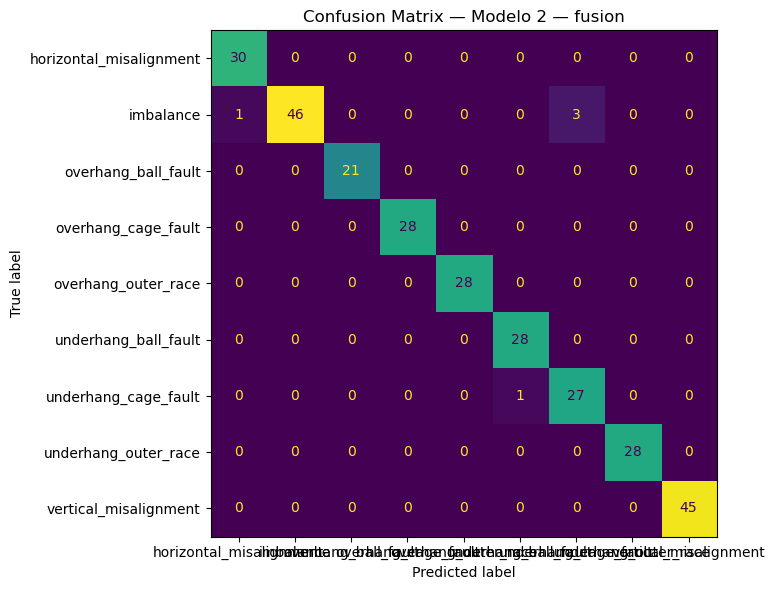

In [ ]:
# 12. REPORTS DETALLADOS DEL MEJOR DOMINIO

mejor_dom_m1 = df_test_m1.sort_values('f1_test', ascending=False).iloc[0]['dominio']
mejor_dom_m2 = df_test_m2.sort_values('f1_test', ascending=False).iloc[0]['dominio']

print(f"\nMejor dominio M1: {mejor_dom_m1}")
print(f"Mejor dominio M2: {mejor_dom_m2}")

# classification report modelo 2 mejor dominio
X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m2[mejor_dom_m2]
acc, f1, y_pred = evaluar_test_clf(clf_m2[mejor_dom_m2], X_tr, X_val, X_te, y_tr, y_val, y_te)

print("\nClassification report — Modelo 2 — mejor dominio")
print(classification_report(y_te, y_pred))

cm = confusion_matrix(y_te, y_pred, labels=sorted(np.unique(y_te)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_te)))
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False)
plt.title(f"Confusion Matrix — Modelo 2 — {mejor_dom_m2}")
plt.tight_layout()
plt.show()

# VISUALIZACIONES

In [ ]:
COLOR_BASE = "#00929a"
COLOR_OSCURO = "#006d73"
COLOR_CLARO = "#4bb8be"
COLOR_MUY_CLARO = "#d9f1f2"
COLOR_GRID = "#b7dfe2"
COLOR_TEXTO = "#1f2d2f"
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#d0d0d0"
plt.rcParams["axes.labelcolor"] = COLOR_TEXTO
plt.rcParams["xtick.color"] = COLOR_TEXTO
plt.rcParams["ytick.color"] = COLOR_TEXTO
plt.rcParams["text.color"] = COLOR_TEXTO
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.frameon"] = False

cmap_teal = LinearSegmentedColormap.from_list("teal_custom",
    ["#ffffff", COLOR_MUY_CLARO, COLOR_CLARO, COLOR_BASE, COLOR_OSCURO])


GENERANDO GRÁFICOS FINALES

[1] CLASIFICACIÓN — MODELO 2


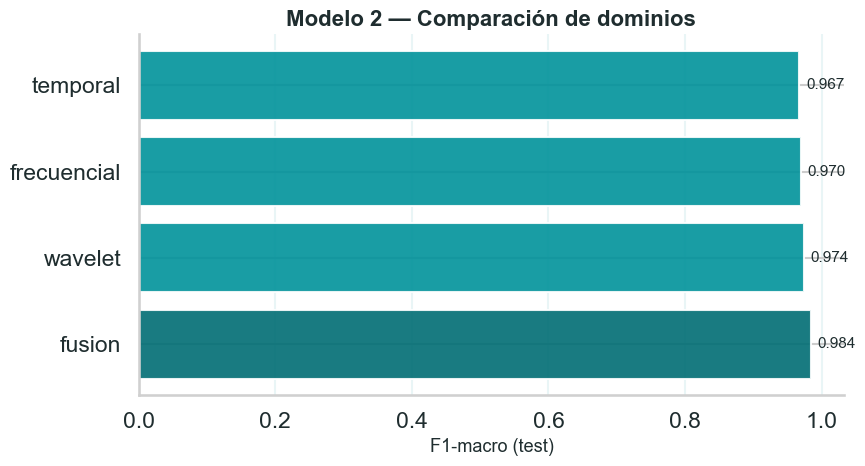

→ Mejor dominio Modelo 2: fusion

[2] VALIDACIÓN vs TEST


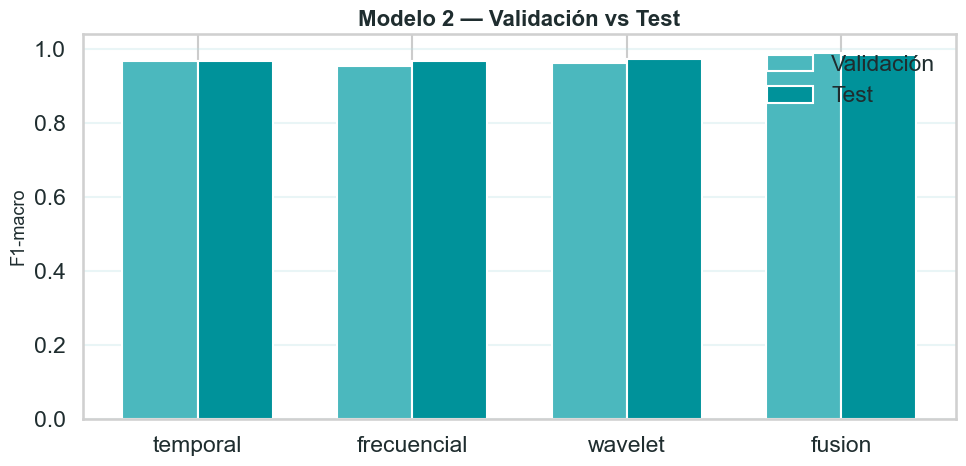


[3] CONFUSION MATRIX


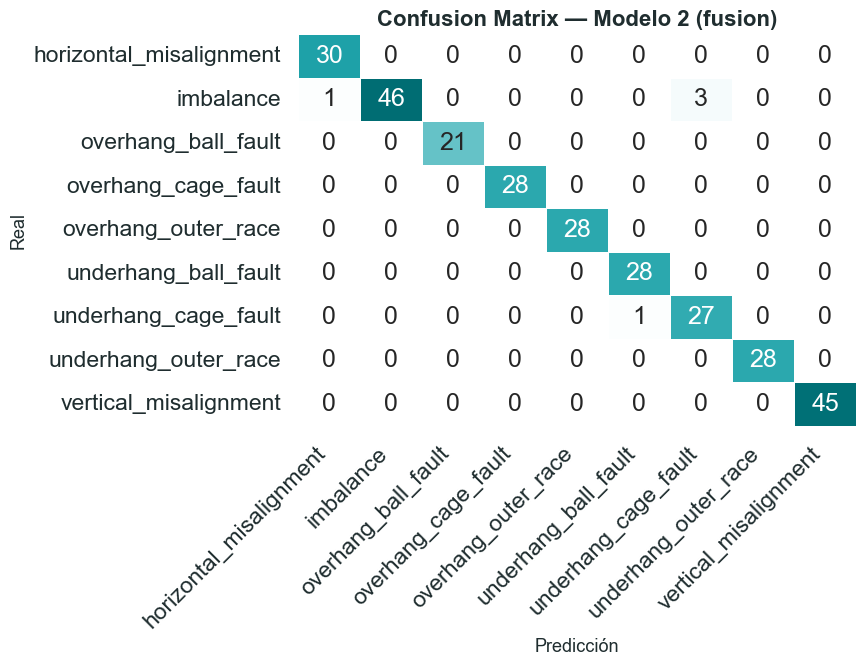


[4] IMPORTANCIA DE VARIABLES


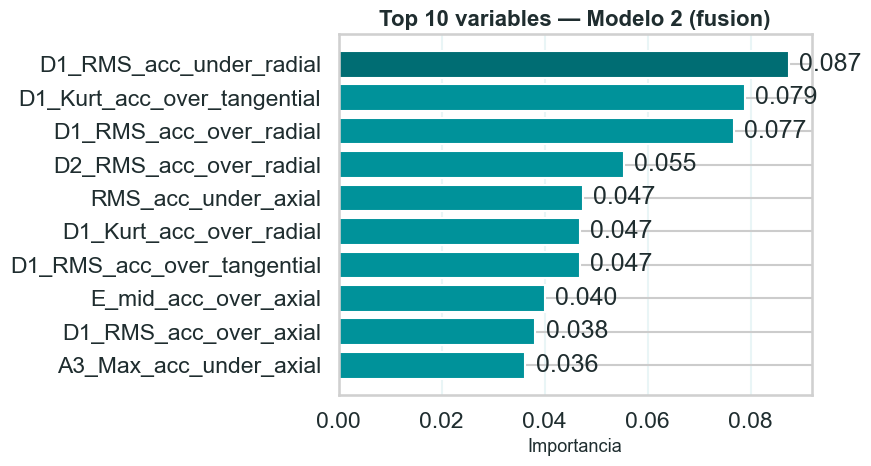

D1_RMS_acc_under_radial        0.087479
D1_Kurt_acc_over_tangential    0.078827
D1_RMS_acc_over_radial         0.076739
D2_RMS_acc_over_radial         0.055390
RMS_acc_under_axial            0.047371
D1_Kurt_acc_over_radial        0.046863
D1_RMS_acc_over_tangential     0.046783
E_mid_acc_over_axial           0.040041
D1_RMS_acc_over_axial          0.038179
A3_Max_acc_under_axial         0.036281
dtype: float64

[5] REGRESIÓN — COMPARACIÓN POR TIPO


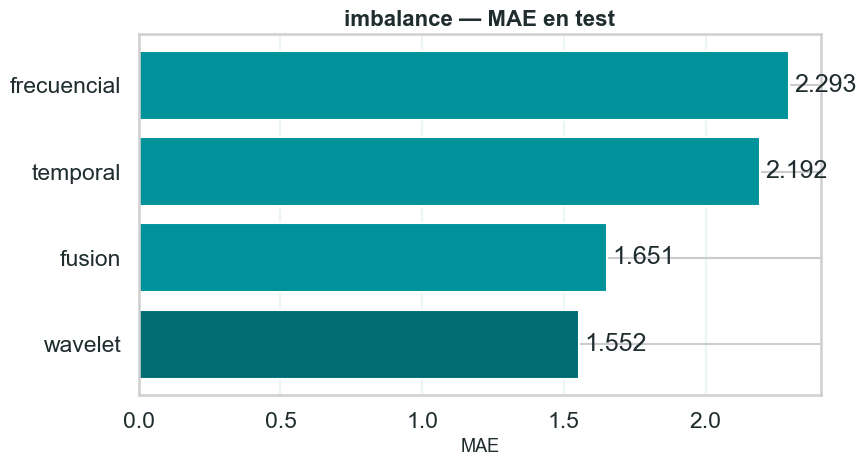

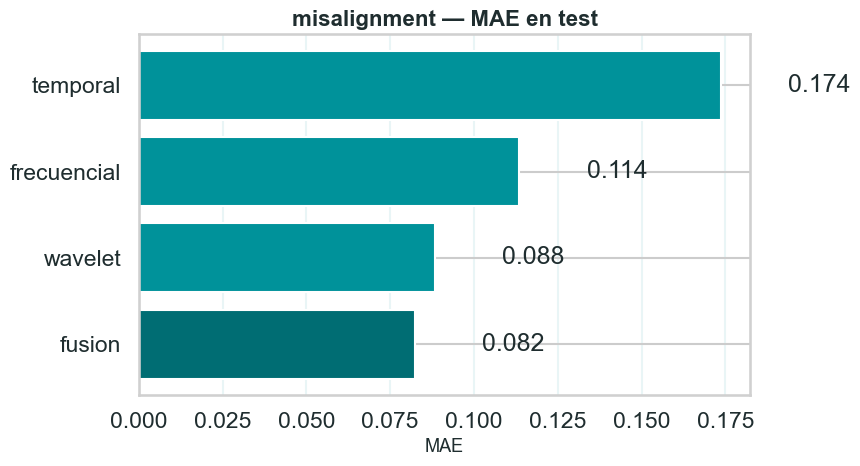

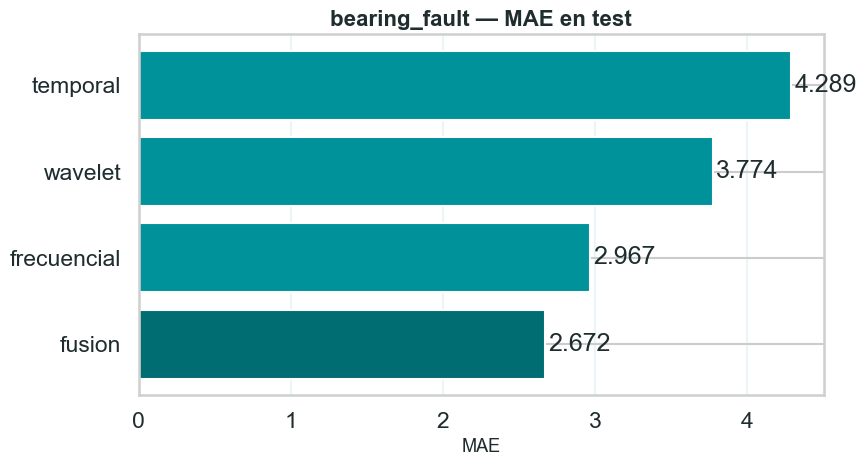


[6] RANKING GLOBAL REGRESIÓN


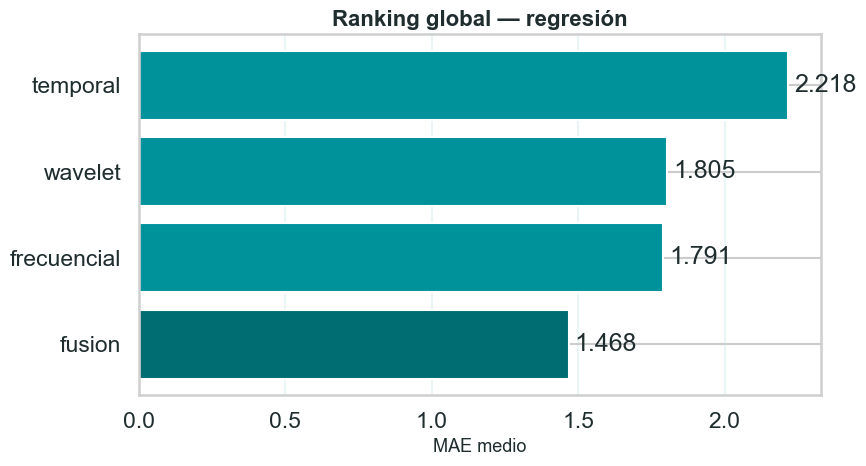

       dominio       mae
1       fusion  1.468350
0  frecuencial  1.791114
3      wavelet  1.804805
2     temporal  2.217980

[7] REAL vs PREDICCIÓN


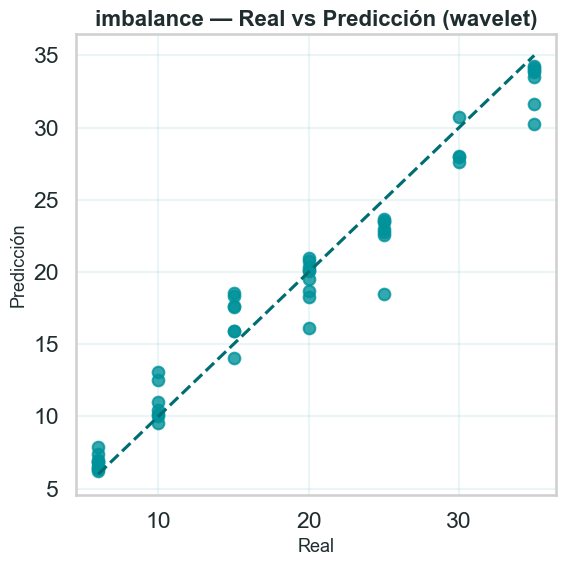

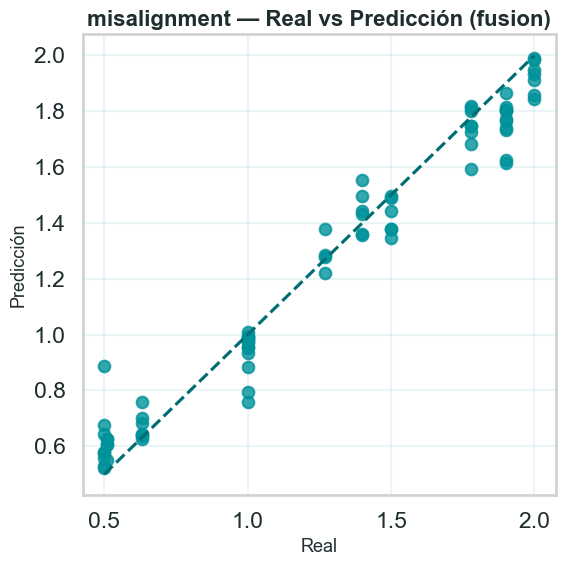

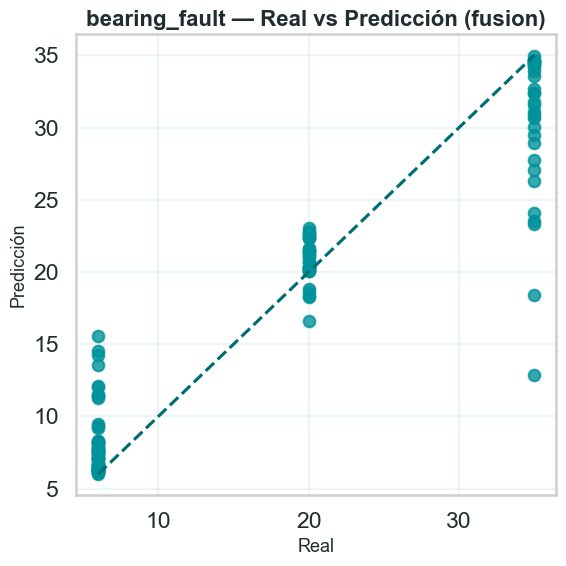

In [ ]:
print("GENERANDO GRÁFICOS FINALES")

# 1. CLASIFICACIÓN — MODELO 2

print("\n[1] CLASIFICACIÓN — MODELO 2")

# Ranking
df_plot_m2 = df_test_m2.sort_values("f1_test", ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 5))
colors = [COLOR_OSCURO if i == 0 else COLOR_BASE for i in range(len(df_plot_m2))]
bars = plt.barh(df_plot_m2["dominio"], df_plot_m2["f1_test"], color=colors, alpha=0.9)
for bar, val in zip(bars, df_plot_m2["f1_test"]):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=11)
plt.xlabel("F1-macro (test)")
plt.title("Modelo 2 — Comparación de dominios")
plt.grid(axis="x", alpha=0.3, color=COLOR_GRID)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

mejor_dom_m2 = df_plot_m2.iloc[0]["dominio"]
print(f"→ Mejor dominio Modelo 2: {mejor_dom_m2}")

# 2. VALIDACIÓN VS TEST (M2)

print("\n[2] VALIDACIÓN vs TEST")
df_plot_val = df_val_m2.merge(df_test_m2, on="dominio")
x = np.arange(len(df_plot_val))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, df_plot_val["f1_val"], width, label="Validación", color=COLOR_CLARO)
plt.bar(x + width/2, df_plot_val["f1_test"], width, label="Test", color=COLOR_BASE)
plt.xticks(x, df_plot_val["dominio"])
plt.ylabel("F1-macro")
plt.title("Modelo 2 — Validación vs Test")
plt.legend()
plt.grid(axis="y", alpha=0.3, color=COLOR_GRID)
plt.tight_layout()
plt.show()

# 3. CONFUSION MATRIX — MEJOR MODELO
print("\n[3] CONFUSION MATRIX")

X_tr, X_val, X_te, y_tr, y_val, y_te = splits_m2[mejor_dom_m2]

acc, f1, y_pred = evaluar_test_clf(
    clf_m2[mejor_dom_m2],X_tr, X_val, X_te,
    y_tr, y_val, y_te)

labels = sorted(np.unique(y_te))
cm = confusion_matrix(y_te, y_pred, labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,annot=True,
    fmt="d",cmap=cmap_teal,
    cbar=False,xticklabels=labels,
    yticklabels=labels,linewidths=0.5,
    linecolor="white")
plt.title(f"Confusion Matrix — Modelo 2 ({mejor_dom_m2})")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 4. IMPORTANCIA DE VARIABLES (M2)

print("\n[4] IMPORTANCIA DE VARIABLES")

nombres_dict_m2 = nombres_m2
importancias = pd.Series(
    clf_m2[mejor_dom_m2].feature_importances_,
    index=nombres_dict_m2[mejor_dom_m2]).sort_values(ascending=False).head(10)
importancias = importancias.sort_values()
plt.figure(figsize=(9, 5))
bars = plt.barh(importancias.index, importancias.values,
                color=[COLOR_BASE]*9 + [COLOR_OSCURO])

for bar, val in zip(bars, importancias.values):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center")
plt.title(f"Top 10 variables — Modelo 2 ({mejor_dom_m2})")
plt.xlabel("Importancia")
plt.grid(axis="x", alpha=0.3, color=COLOR_GRID)
plt.tight_layout()
plt.show()
print(importancias.sort_values(ascending=False))

# 5. REGRESIÓN — COMPARACIÓN POR TIPO

print("\n[5] REGRESIÓN — COMPARACIÓN POR TIPO")
for tipo in ["imbalance", "misalignment", "bearing_fault"]:
    df_tmp = df_test_reg[df_test_reg["tipo"] == tipo].sort_values("mae_test")

    plt.figure(figsize=(9, 5))

    colors = [COLOR_OSCURO if i == 0 else COLOR_BASE for i in range(len(df_tmp))]

    bars = plt.barh(df_tmp["dominio"], df_tmp["mae_test"], color=colors)

    for bar, val in zip(bars, df_tmp["mae_test"]):
        plt.text(bar.get_width() + 0.02,
                 bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center")

    plt.title(f"{tipo} — MAE en test")
    plt.xlabel("MAE")
    plt.grid(axis="x", alpha=0.3, color=COLOR_GRID)
    plt.tight_layout()
    plt.show()

# 6. REGRESIÓN — RANKING GLOBAL

print("\n[6] RANKING GLOBAL REGRESIÓN")

ranking = (
    df_test_reg
    .groupby("dominio", as_index=False)
    .agg(mae=("mae_test", "mean"))
    .sort_values("mae")
)

plt.figure(figsize=(9, 5))

bars = plt.barh(ranking["dominio"], ranking["mae"],
                color=[COLOR_OSCURO] + [COLOR_BASE]*(len(ranking)-1))

for bar, val in zip(bars, ranking["mae"]):
    plt.text(bar.get_width() + 0.02,
             bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center")

plt.title("Ranking global — regresión")
plt.xlabel("MAE medio")
plt.grid(axis="x", alpha=0.3, color=COLOR_GRID)
plt.tight_layout()
plt.show()

print(ranking)

# 7. REAL vs PREDICCIÓN (MEJOR DE CADA TIPO)

print("\n[7] REAL vs PREDICCIÓN")

for tipo in ["imbalance", "misalignment", "bearing_fault"]:

    df_tmp = df_test_reg[df_test_reg["tipo"] == tipo].sort_values("mae_test")
    mejor_dom = df_tmp.iloc[0]["dominio"]

    X_tr, X_val, X_te, y_tr, y_val, y_te = splits_reg[tipo][mejor_dom]
    reg = reg_models[tipo][mejor_dom]

    X_train_final = np.vstack([X_tr, X_val])
    y_train_final = np.hstack([y_tr, y_val])

    reg.fit(X_train_final, y_train_final)
    pred = reg.predict(X_te)

    plt.figure(figsize=(6, 6))

    plt.scatter(y_te, pred, color=COLOR_BASE, s=70, alpha=0.8)

    lim_min = min(min(y_te), min(pred))
    lim_max = max(max(y_te), max(pred))

    plt.plot([lim_min, lim_max], [lim_min, lim_max],
             '--', color=COLOR_OSCURO)

    plt.title(f"{tipo} — Real vs Predicción ({mejor_dom})")
    plt.xlabel("Real")
    plt.ylabel("Predicción")
    plt.grid(alpha=0.3, color=COLOR_GRID)
    plt.tight_layout()
    plt.show()

# GUARDAR MODLEOS, CSV... --> BIG DATA

In [ ]:
SAVE_DIR = "Modelos"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# MODELOS CLASIFICACIÓN

for dom in clf_m1:
    joblib.dump(clf_m1[dom], f"{SAVE_DIR}/clf_m1_{dom}.joblib")

for dom in clf_m2:
    joblib.dump(clf_m2[dom], f"{SAVE_DIR}/clf_m2_{dom}.joblib")

print("Modelos de clasificación guardados")

✓ Modelos de clasificación guardados


In [ ]:
# MODELOS REGRESIÓN

for tipo in reg_models:
    for dom in reg_models[tipo]:
        joblib.dump(
            reg_models[tipo][dom],
            f"{SAVE_DIR}/reg_{tipo}_{dom}.joblib")

print("✓ Modelos de regresión guardados")

✓ Modelos de regresión guardados


In [ ]:
# DATASET COMPLETO

df_features = pd.DataFrame(X_total, columns=nombres_total)

df_features['y_fault'] = y_fault
df_features['y_tipo'] = y_tipo
df_features['y_tipo_det'] = y_tipo_det
df_features['y_severidad'] = y_sev

df_features.to_csv(f"{SAVE_DIR}/dataset_features_total.csv", index=False)

print("CSV completo guardado")

✓ CSV completo guardado


### CSV CON FEATURES SELECCIONADAS

In [ ]:
# Modelo 1
for dom in dominios_m1:
    df = pd.DataFrame(
        dominios_m1[dom],
        columns=nombres_m1[dom])
    df['y'] = y_fault

    df.to_csv(f"{SAVE_DIR}/features_m1_{dom}.csv", index=False)

In [22]:
# Modelo 2
for dom in dominios_m2:
    df = pd.DataFrame(
        dominios_m2[dom],
        columns=nombres_m2[dom]
    )
    df['y'] = y2

    df.to_csv(f"{SAVE_DIR}/features_m2_{dom}.csv", index=False)

In [23]:
# Modelo 3
for tipo in dominios_reg:
    for dom in dominios_reg[tipo]:
        df = pd.DataFrame(
            dominios_reg[tipo][dom],
            columns=nombres_reg[tipo][dom]
        )

        mask = (y_tipo == tipo) & (y_sev > 0)
        df['y'] = y_sev[mask]

        df.to_csv(f"{SAVE_DIR}/features_reg_{tipo}_{dom}.csv", index=False)

### NOMBRES DE FEATURES

In [ ]:
joblib.dump(nombres_m1, f"{SAVE_DIR}/nombres_m1.joblib")
joblib.dump(nombres_m2, f"{SAVE_DIR}/nombres_m2.joblib")
joblib.dump(nombres_reg, f"{SAVE_DIR}/nombres_reg.joblib")

print("Nombres de features guardados")

✓ Nombres de features guardados


modelo = joblib.load("clf_m2_fusion.joblib")

features = joblib.load("nombres_m2.joblib")['fusion']

X_nuevo = df_nuevo[features]

pred = modelo.predict(X_nuevo)

In [ ]:
df_meta = pd.DataFrame(meta_registros)
df_meta.to_csv(f"{SAVE_DIR}/metadata.csv", index=False)

print("Metadata guardada")

✓ Metadata guardada


In [ ]:
metadata = {
    "fs": 51200,
    "model_name": "clf_m2_fusion",
    "task": "fault_type_classification",
    "selected_features": "nombres_m2['fusion']"
}

joblib.dump(metadata, "Modelos/metadata.joblib")

['metadata.joblib']

# MÁS GRAFICOS

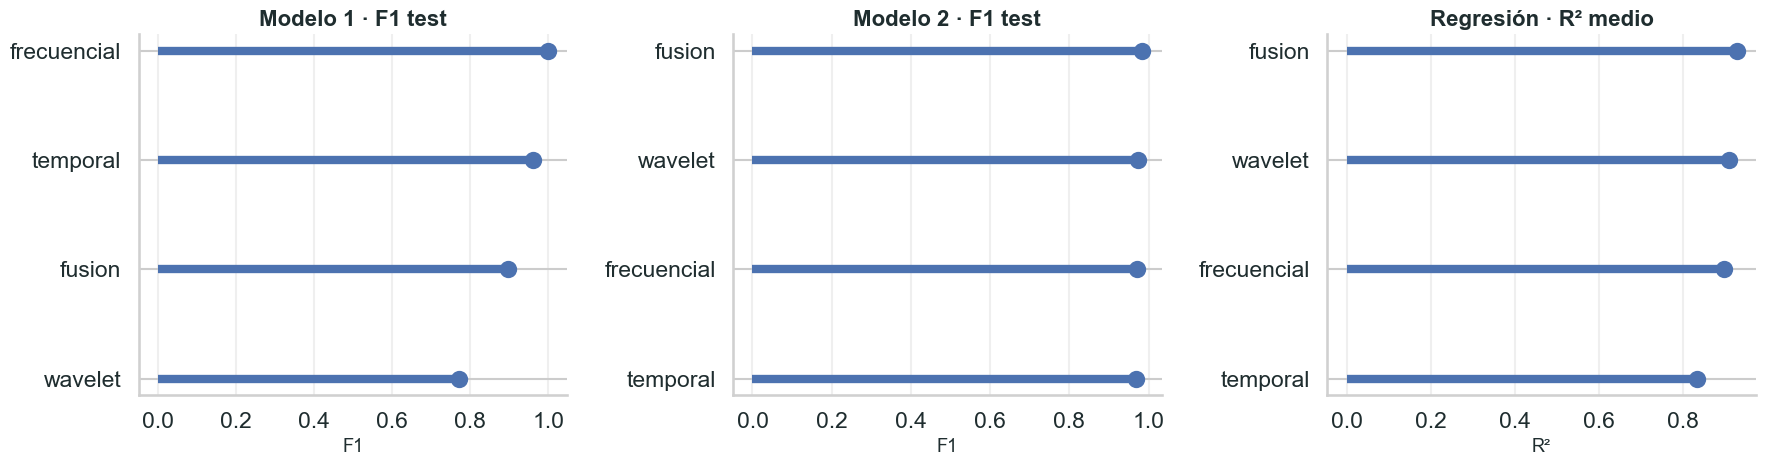

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# M1
tmp1 = df_test_m1.sort_values("f1_test", ascending=True)
axes[0].hlines(tmp1["dominio"], xmin=0, xmax=tmp1["f1_test"], linewidth=6)
axes[0].scatter(tmp1["f1_test"], tmp1["dominio"], s=120)
axes[0].set_title("Modelo 1 · F1 test")
axes[0].set_xlabel("F1")
axes[0].grid(axis="x", alpha=0.3)

# M2
tmp2 = df_test_m2.sort_values("f1_test", ascending=True)
axes[1].hlines(tmp2["dominio"], xmin=0, xmax=tmp2["f1_test"], linewidth=6)
axes[1].scatter(tmp2["f1_test"], tmp2["dominio"], s=120)
axes[1].set_title("Modelo 2 · F1 test")
axes[1].set_xlabel("F1")
axes[1].grid(axis="x", alpha=0.3)

# Regresión
tmp3 = df_test_reg.groupby("dominio", as_index=False)["r2_test"].mean().sort_values("r2_test", ascending=True)
axes[2].hlines(tmp3["dominio"], xmin=0, xmax=tmp3["r2_test"], linewidth=6)
axes[2].scatter(tmp3["r2_test"], tmp3["dominio"], s=120)
axes[2].set_title("Regresión · R² medio")
axes[2].set_xlabel("R²")
axes[2].grid(axis="x", alpha=0.3)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


GENERANDO GRÁFICOS WOW

[WOW 1] SLOPE CHART — MODELO 2


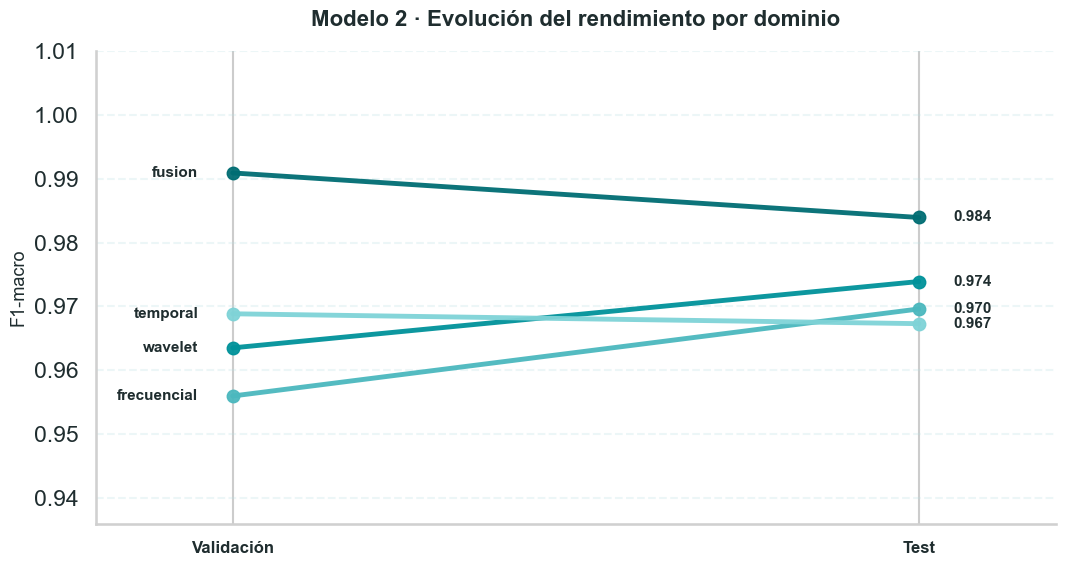


[WOW 2] HEATMAP EJECUTIVO


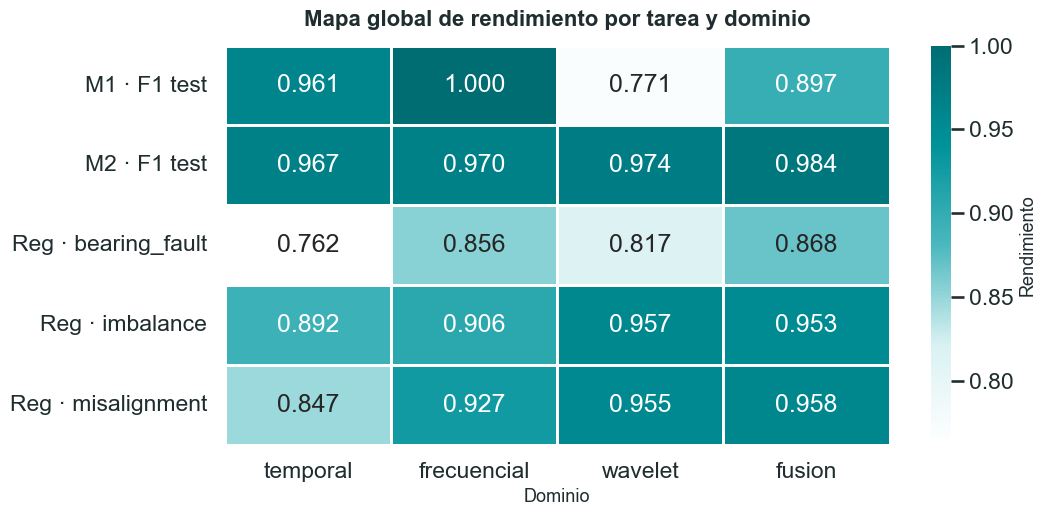


[WOW 3] BUBBLE CHART — REGRESIÓN


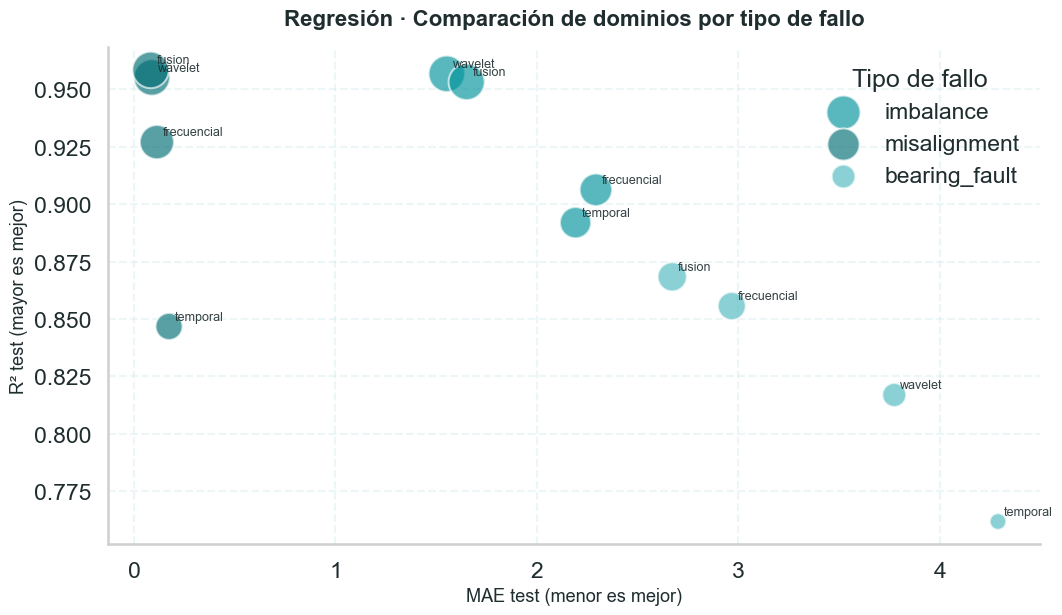

In [ ]:
print("GENERANDO GRÁFICOS WOW")

# 1. SLOPE CHART — VALIDACIÓN vs TEST (MODELO 2)
print("\n[WOW 1] SLOPE CHART — MODELO 2")

df_slope = (
    df_val_m2.merge(df_test_m2, on="dominio")
    [["dominio", "f1_val", "f1_test"]]
    .sort_values("f1_test", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 6))

x = [0, 1]
palette = [COLOR_OSCURO, COLOR_BASE, COLOR_CLARO, "#7fd3d7"]

for i, row in df_slope.iterrows():
    y = [row["f1_val"], row["f1_test"]]
    color = palette[i % len(palette)]

    ax.plot(x, y, marker="o", linewidth=3.5, markersize=9, color=color, alpha=0.95)

    ax.text(-0.05, row["f1_val"], row["dominio"],
            ha="right", va="center", fontsize=11, fontweight="bold")
    ax.text(1.05, row["f1_test"], f'{row["f1_test"]:.3f}',
            ha="left", va="center", fontsize=11, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Validación", "Test"], fontsize=12, fontweight="bold")
ax.set_ylabel("F1-macro")
ax.set_title("Modelo 2 · Evolución del rendimiento por dominio", pad=18)
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(min(df_slope[["f1_val", "f1_test"]].min()) - 0.02, 1.01)
ax.grid(axis="y", alpha=0.25, color=COLOR_GRID, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# 2. HEATMAP EJECUTIVO — RESUMEN GLOBAL

print("\n[WOW 2] HEATMAP EJECUTIVO")

heat_m1 = df_test_m1.set_index("dominio")[["f1_test"]].T
heat_m1.index = ["M1 · F1 test"]

heat_m2 = df_test_m2.set_index("dominio")[["f1_test"]].T
heat_m2.index = ["M2 · F1 test"]

heat_reg = df_test_reg.pivot(index="tipo", columns="dominio", values="r2_test")
heat_reg.index = [f"Reg · {i}" for i in heat_reg.index]

heat_total = pd.concat([heat_m1, heat_m2, heat_reg], axis=0)

plt.figure(figsize=(11, 5.5))
sns.heatmap(
    heat_total,
    annot=True,
    fmt=".3f",
    cmap=cmap_teal,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Rendimiento"}
)

plt.title("Mapa global de rendimiento por tarea y dominio", pad=14)
plt.xlabel("Dominio")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. BUBBLE CHART — REGRESIÓN POR TIPO
print("\n[WOW 3] BUBBLE CHART — REGRESIÓN")

df_bubble = df_test_reg.copy()
r2_min = df_bubble["r2_test"].min()
df_bubble["bubble_size"] = (df_bubble["r2_test"] - r2_min + 0.05) * 2800

tipo_color = {
    "imbalance": COLOR_BASE,
    "misalignment": COLOR_OSCURO,
    "bearing_fault": COLOR_CLARO
}

fig, ax = plt.subplots(figsize=(11, 6.5))

for tipo in ["imbalance", "misalignment", "bearing_fault"]:
    sub = df_bubble[df_bubble["tipo"] == tipo]

    ax.scatter(
        sub["mae_test"],
        sub["r2_test"],
        s=sub["bubble_size"],
        alpha=0.65,
        color=tipo_color[tipo],
        edgecolors="white",
        linewidth=1.5,
        label=tipo
    )

    for _, row in sub.iterrows():
        ax.text(
            row["mae_test"] + 0.03,
            row["r2_test"] + 0.003,
            row["dominio"],
            fontsize=9,
            alpha=0.9
        )

ax.set_title("Regresión · Comparación de dominios por tipo de fallo", pad=16)
ax.set_xlabel("MAE test (menor es mejor)")
ax.set_ylabel("R² test (mayor es mejor)")
ax.grid(alpha=0.25, color=COLOR_GRID, linestyle="--")
ax.legend(title="Tipo de fallo")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

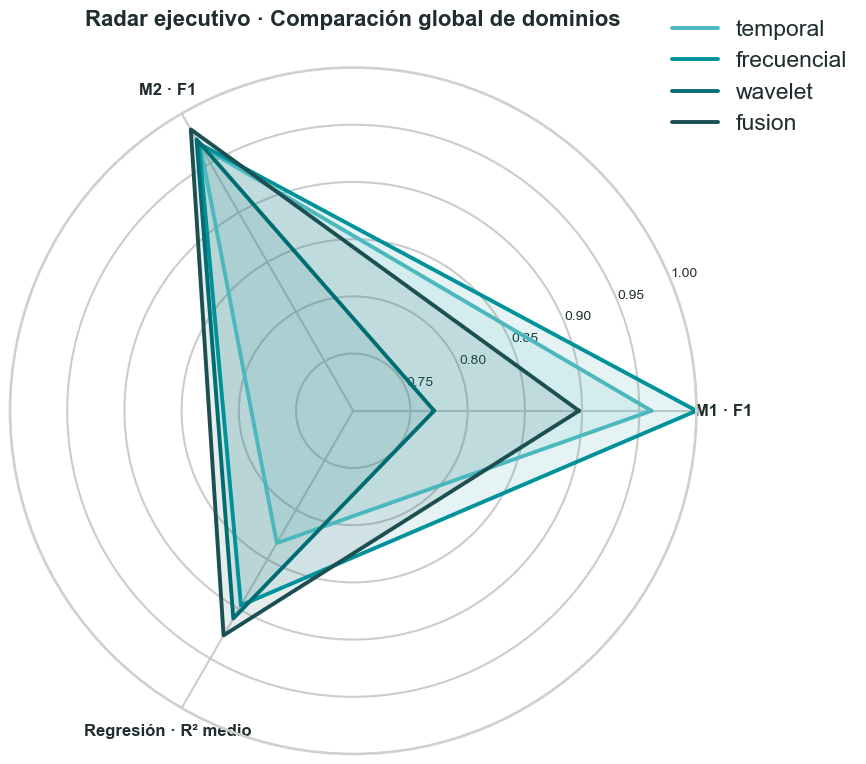

In [ ]:
radar_df = pd.DataFrame({
    "dominio": ["temporal", "frecuencial", "wavelet", "fusion"],
    "M1_F1": df_test_m1.set_index("dominio").loc[["temporal", "frecuencial", "wavelet", "fusion"], "f1_test"].values,
    "M2_F1": df_test_m2.set_index("dominio").loc[["temporal", "frecuencial", "wavelet", "fusion"], "f1_test"].values,
    "Reg_R2_medio": (
        df_test_reg.groupby("dominio")["r2_test"].mean()
        .loc[["temporal", "frecuencial", "wavelet", "fusion"]]
        .values)})

categories = ["M1_F1", "M2_F1", "Reg_R2_medio"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

color_map = {
    "temporal": COLOR_CLARO,
    "frecuencial": COLOR_BASE,
    "wavelet": COLOR_OSCURO,
    "fusion": "#1c4f52"
}

for _, row in radar_df.iterrows():
    values = [row[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2.8, label=row["dominio"], color=color_map[row["dominio"]])
    ax.fill(angles, values, alpha=0.10, color=color_map[row["dominio"]])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["M1 · F1", "M2 · F1", "Regresión · R² medio"], fontsize=12, fontweight="bold")
ax.set_ylim(0.70, 1.00)
ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.00])
ax.set_yticklabels(["0.75", "0.80", "0.85", "0.90", "0.95", "1.00"], fontsize=10)
ax.set_title("Radar ejecutivo · Comparación global de dominios", pad=30, fontsize=16, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
plt.show()